# Assignment: Decision Trees and Random Forests on Dry Bean Classification

## Objective

A food-processing system measures the shape of individual dry beans. Your task is to build a model that classifies each bean into one of seven varieties.

This is an experiment-driven assignment. You will change one modeling choice at a time, measure what changes, and explain why.

## Learning outcomes

By completing this assignment, you should be able to:

- recognize underfitting and overfitting in a Decision Tree;
- control tree complexity using depth and leaf-size parameters;
- compare Gini impurity, entropy, and log loss as split criteria;
- study how the number of trees affects a Random Forest;
- explain why random feature sampling creates diversity;
- interpret built-in Decision Tree and Random Forest feature importance;
- select a model using validation data and evaluate it once on unseen test data.

**Expected effort:** approximately 2-3 hours.


## Dataset

We will use the **UCI Dry Bean dataset**. Images of 13,611 bean grains were processed to produce 16 numerical shape measurements. The target contains seven registered bean varieties:

`SEKER`, `BARBUNYA`, `BOMBAY`, `CALI`, `DERMASON`, `HOROZ`, and `SIRA`.

Examples of input features include area, perimeter, major-axis length, eccentricity, roundness, compactness, and shape factors.

Dataset page: <https://archive.ics.uci.edu/dataset/602/dry+bean>

The loading code is provided. Your work begins with understanding the data and building the experiments.


## Assignment rules

1. Complete every `TODO` cell and remove its `NotImplementedError`.
2. Keep `RANDOM_STATE = 42` so results remain reproducible.
3. Use the **training set** to fit models.
4. Use the **validation set** to compare settings and select the final model.
5. Do not inspect test performance while tuning.
6. Evaluate the test set only once, after making the final model choice.
7. For every experiment, change only the parameter being studied.


## 1. Setup

Run the installation cell only if a package is missing.


In [1]:
# Run this only if required.
# %pip install numpy pandas matplotlib seaborn scikit-learn ucimlrepo


In [2]:
import time
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)


## 2. Load the Dry Bean Dataset


In [3]:
# UCI dataset ID 602: Dry Bean
dry_bean = fetch_ucirepo(id=602)

X = dry_bean.data.features.copy()
y = dry_bean.data.targets["Class"].copy()

# Remove exact duplicate observations before splitting. Otherwise, identical
# rows could appear in both the training and evaluation sets.
data = pd.concat([X, y.rename("Class")], axis=1)
duplicate_count = data.duplicated().sum()
data = data.drop_duplicates().reset_index(drop=True)

X = data.drop(columns="Class")
y = data["Class"]

print("Exact duplicates removed:", duplicate_count)
print("Feature shape after cleaning:", X.shape)
print("Target shape after cleaning:", y.shape)
X.head()


Exact duplicates removed: 68
Feature shape after cleaning: (13543, 16)
Target shape after cleaning: (13543,)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166


In [4]:
# Basic checks supplied for you.
print("Missing feature values:", X.isna().sum().sum())
print("Duplicate observations remaining:", pd.concat([X, y], axis=1).duplicated().sum())
print("Target classes:", sorted(y.unique()))


Missing feature values: 0
Duplicate observations remaining: 0
Target classes: ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']


## 3. Understand the Data

Before fitting a model, inspect the feature ranges and class distribution.

All inputs are numerical. Decision Trees and Random Forests compare feature thresholds, so scaling is not required for these models.

### TODO

- Display descriptive statistics for all features.
- Create a table containing the count and percentage of each bean class.
- Plot the class counts.


In [5]:
# TODO: Display descriptive statistics for the numerical features.
X.describe()


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000
mean,53048.460385,854.993406,319.895602,202.365321,1.581075,0.750315,53767.986709,253.034094,0.749829,0.987152,0.873671,0.800352,0.006561,0.001719,0.644341,0.995078
std,29392.438324,214.722684,85.809260,45.051632,0.245245,0.091858,29844.248525,59.307709,0.048939,0.004650,0.059393,0.061464,0.001130,0.000595,0.098653,0.004347
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36282.500000,703.230000,253.086806,175.886357,1.430662,0.715144,36673.000000,214.933277,0.718735,0.985678,0.833410,0.763228,0.005893,0.001158,0.582517,0.993720
50%,44580.000000,793.896000,296.404589,192.491117,1.549860,0.763997,45122.000000,238.245711,0.759903,0.988288,0.883490,0.801514,0.006643,0.001700,0.642424,0.996393
75%,61382.000000,977.146500,376.312489,217.245403,1.703916,0.809671,62360.000000,279.560351,0.786849,0.990019,0.917031,0.834470,0.007270,0.002173,0.696341,0.997891
max,254616.000000,1985.370000,738.860154,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


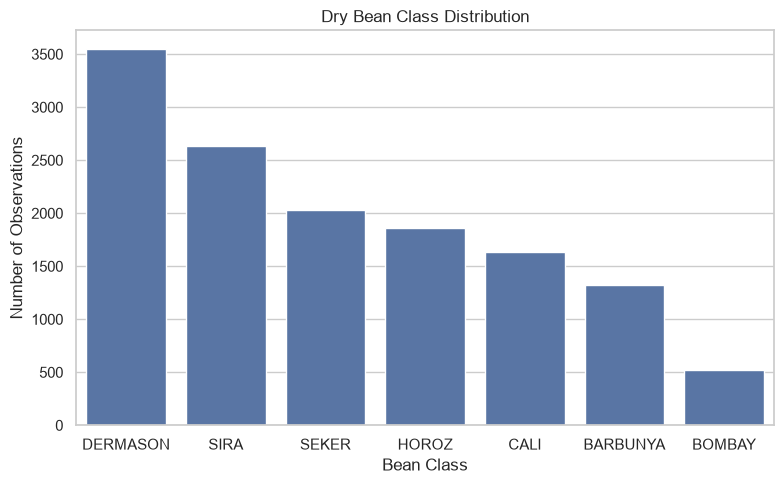

In [6]:
# TODO: Create a class-distribution table with Count and Percentage columns.
# TODO: Plot the number of observations in every class.

# Create a class-distribution table with Count and Percentage columns.
class_distribution = y.value_counts().rename_axis("Class").reset_index(name="Count")
class_distribution["Percentage"] = (
    class_distribution["Count"] / len(y) * 100
).round(2)

class_distribution

# Plot the number of observations in every class.
plt.figure(figsize=(8, 5))
sns.barplot(data=class_distribution, x="Class", y="Count")
plt.title("Dry Bean Class Distribution")
plt.xlabel("Bean Class")
plt.ylabel("Number of Observations")
plt.tight_layout()
plt.show()

### Question 1

1. Are all classes equally represented?
2. Why will **macro F1-score** be useful in addition to accuracy for this multiclass problem?

**Your answer:**

- 1) No, not all class have equal number of record count.
- 2) **Equal class weighting:** Every class contributes equally to the final score, regardless of how many samples it has in the dataset.
**Robust evaluation:** It forces the model to perform well on rare classes to achieve a high overall score.
**Balance of metrics:** It combines precision and recall, ensuring the model minimizes both false positives and false negatives for every category.

## 4. Create Train, Validation, and Test Sets

Use a **60% training, 20% validation, and 20% test** split.

Apply stratification during both splitting steps so all seven classes retain similar proportions.

The validation set is used for experiments and model selection. The test set represents completely unseen data.


In [7]:
# First hold out 20% of the full dataset for final testing.
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

# Split the remaining 80% into 75% training and 25% validation.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    stratify=y_train_val,
    random_state=RANDOM_STATE,
)

In [8]:
split_objects = {
    "X_train": X_train,
    "y_train": y_train,
    "X_val": X_val,
    "y_val": y_val,
    "X_test": X_test,
    "y_test": y_test,
}

print("Shapes of the six split objects:")
for name, values in split_objects.items():
    print(f"{name}: {values.shape}")

class_percentages = pd.DataFrame({
    "Train (%)": y_train.value_counts(normalize=True) * 100,
    "Validation (%)": y_val.value_counts(normalize=True) * 100,
    "Test (%)": y_test.value_counts(normalize=True) * 100,
}).sort_index().round(2)
class_percentages.index.name = "Class"

print("\nClass distribution by split:")
display(class_percentages)

Shapes of the six split objects:
X_train: (8125, 16)
y_train: (8125,)
X_val: (2709, 16)
y_val: (2709,)
X_test: (2709, 16)
y_test: (2709,)

Class distribution by split:


,Train (%),Validation (%),Test (%)
Class,,,
BARBUNYA,9.76,9.75,9.78
BOMBAY,3.85,3.88,3.84
CALI,12.04,12.03,12.03
DERMASON,26.18,26.21,26.17
HOROZ,13.74,13.73,13.73
SEKER,14.97,14.95,14.99
SIRA,19.47,19.45,19.45


### Question 2

Why should the test set remain untouched until the final model has been selected?

**Your answer:**

- to prevent data leakage and ensure an unbiased evaluation of the model's real-world performance


## 5. Evaluation Helpers

These helpers are provided so that your experiments use consistent metrics.


In [9]:
def classification_metrics(y_true, y_pred):
    # Return metrics suitable for multiclass model comparison.
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }


def fit_and_measure(model, X_train, y_train, X_eval, y_eval):
    # Fit a fresh model and return train/evaluation metrics plus training time.
    fitted_model = clone(model)
    start = time.perf_counter()
    fitted_model.fit(X_train, y_train)
    fit_seconds = time.perf_counter() - start

    train_pred = fitted_model.predict(X_train)
    eval_pred = fitted_model.predict(X_eval)

    return fitted_model, {
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Validation Accuracy": accuracy_score(y_eval, eval_pred),
        "Validation Macro F1": f1_score(y_eval, eval_pred, average="macro", zero_division=0),
        "Fit Time (s)": fit_seconds,
    }


## 6. Baseline Decision Tree

First train an unrestricted Decision Tree. This gives the tree enough freedom to keep splitting until its stopping rules are reached.

### Before running the model

Do you expect its training accuracy to be low or high? What do you expect on validation data?

**Your prediction:**

-


In [10]:
# Create an unrestricted Decision Tree and measure its training and validation performance.
baseline_tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
baseline_tree, baseline_tree_metrics = fit_and_measure(
    baseline_tree, X_train, y_train, X_val, y_val
)
display(pd.Series(baseline_tree_metrics, name="Baseline Decision Tree"))

Train Accuracy         1.000000
Validation Accuracy    0.889258
Validation Macro F1    0.904803
Fit Time (s)           0.881717
Name: Baseline Decision Tree, dtype: float64

Tree depth: 24
Number of leaves: 562


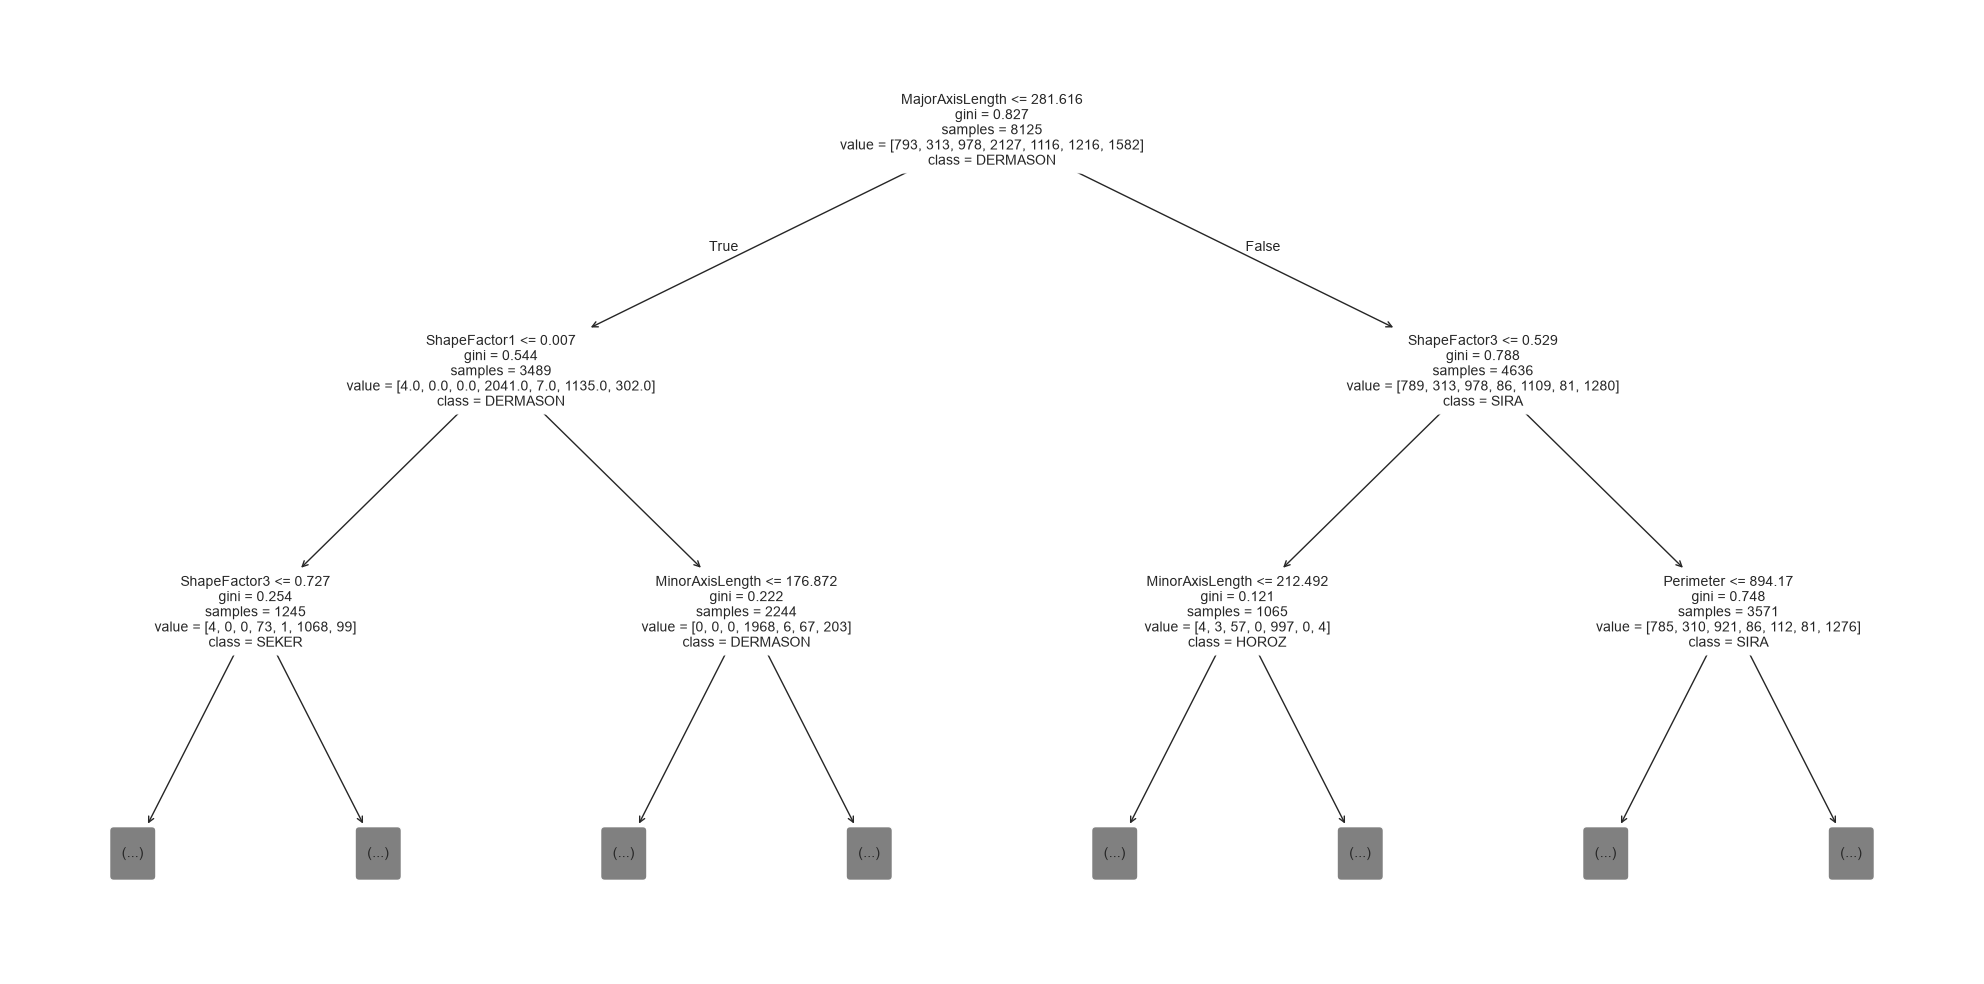

In [11]:
# TODO: Report the fitted tree's depth and number of leaves.
print("Tree depth:", baseline_tree.get_depth())
print("Number of leaves:", baseline_tree.get_n_leaves())

# TODO: Plot only the first three levels of the tree so the figure remains readable.
plt.figure(figsize=(20, 10))
plot_tree(
    baseline_tree,
    feature_names=X.columns,
    class_names=baseline_tree.classes_,
    filled=False,
    rounded=True,
    impurity=True,
    proportion=False,
    max_depth=2,
    fontsize=10,
)
plt.tight_layout()
plt.show()

### Question 3

Compare training and validation accuracy. What evidence of overfitting or underfitting do you observe?

**Your answer:**

- Training accuracy is 1.000, while validation accuracy is 0.889. This gap indicates overfitting: the unrestricted tree fits the training data nearly perfectly but performs less well on unseen validation data. Its many specific leaf nodes can memorize training patterns, which hurts generalization.

## 7. Experiment 1: Maximum Tree Depth

`max_depth` limits how many levels the tree can grow.

Test:

```python
[1, 2, 3, 5, 10, None]
```

Keep all other model settings unchanged.

### Before running the experiment

Sketch or describe how you expect training and validation accuracy to change as depth increases.


In [12]:
depth_values = [1, 2, 3, 5, 10, None]
depth_records = []
# TODO: Train one Decision Tree for every max_depth value.
for max_depth in depth_values:
    depth_model = DecisionTreeClassifier(
        max_depth=max_depth,
        random_state=RANDOM_STATE,
    )
    fitted_depth_model, depth_metrics = fit_and_measure(
        depth_model, X_train, y_train, X_val, y_val
    )
    # TODO: Store max_depth, train accuracy, validation accuracy,
    # validation macro F1, actual tree depth, and number of leaves.
    depth_records.append({
        "max_depth": max_depth,
        "train_accuracy": depth_metrics["Train Accuracy"],
        "validation_accuracy": depth_metrics["Validation Accuracy"],
        "validation_macro_f1": depth_metrics["Validation Macro F1"],
        "actual_depth": fitted_depth_model.get_depth(),
        "number_of_leaves": fitted_depth_model.get_n_leaves(),
    })
# TODO: Convert the collected results into depth_results DataFrame.
depth_results = pd.DataFrame(depth_records)
display(depth_results)

,max_depth,train_accuracy,validation_accuracy,validation_macro_f1,actual_depth,number_of_leaves
0,1.0,0.408738,0.410114,0.163249,1,2
1,2.0,0.653415,0.653008,0.453493,2,4
2,3.0,0.776369,0.776301,0.597602,3,8
3,5.0,0.892554,0.883352,0.887071,5,32
4,10.0,0.969231,0.909930,0.923272,10,282
5,NaN,1.000000,0.889258,0.904803,24,562


Depth labels: ['1', '2', '3', '5', '10', 'Unlimited']


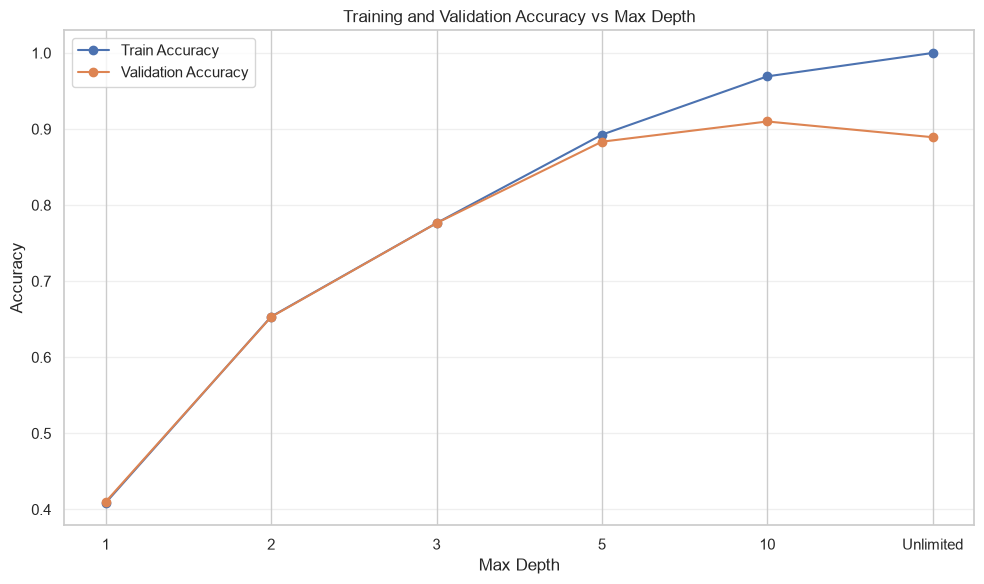

In [13]:
# Plot training and validation accuracy against max_depth.
fig, ax = plt.subplots(figsize=(10, 6))
depth_labels = ["Unlimited" if pd.isna(value) else str(int(value)) for value in depth_results["max_depth"]]
print("Depth labels:", depth_labels)
ax.plot(depth_labels, depth_results["train_accuracy"], marker="o", label="Train Accuracy")
ax.plot(depth_labels, depth_results["validation_accuracy"], marker="o", label="Validation Accuracy")
ax.set_xlabel("Max Depth")
ax.set_ylabel("Accuracy")
ax.set_title("Training and Validation Accuracy vs Max Depth")
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

### Question 4

1. Which depth underfits?
2. Where does validation performance become strong?
3. At what point does additional depth mainly improve training performance?

**Your answer:**

- 1) Depth 2 underfits.
- 2) depth 4 good fit.
- 3) after 3 additional depth mainly improve training performance but wrose validation


## 8. Experiment 2: Minimum Samples per Leaf

`min_samples_leaf` controls the minimum number of training observations allowed in every leaf.

Test:

```python
[1, 2, 5, 10, 20, 50]
```

For this experiment, use the single `max_depth` value that performed best in Experiment 1. Keep it fixed for every run.

### Before running the experiment

How should increasing the minimum leaf size affect tree complexity?


In [14]:
leaf_values = [1, 2, 5, 10, 20, 50]
leaf_records = []
selected_depth = 10  #None  # TODO: Replace using Experiment 1, not test results.
# TODO: Train and evaluate one tree for every min_samples_leaf value.
for min_samples_leaf in leaf_values:
    leaf_model = DecisionTreeClassifier(
        max_depth=selected_depth,
        min_samples_leaf=min_samples_leaf,
        random_state=RANDOM_STATE,
    )
    fitted_leaf_model, leaf_metrics = fit_and_measure(
        leaf_model, X_train, y_train, X_val, y_val
    )
# TODO: Store train accuracy, validation accuracy, validation macro F1,
# actual depth, and number of leaves in leaf_results.
    leaf_records.append({
    "min_samples_leaf": min_samples_leaf,
    "train_accuracy": leaf_metrics["Train Accuracy"],
    "validation_accuracy": leaf_metrics["Validation Accuracy"],
    "validation_macro_f1": leaf_metrics["Validation Macro F1"],
    "actual_depth": fitted_leaf_model.get_depth(),
    "number_of_leaves": fitted_leaf_model.get_n_leaves(),
})
# TODO: Convert the collected results into leaf_results DataFrame.
leaf_results = pd.DataFrame(leaf_records)
display(leaf_results)

,min_samples_leaf,train_accuracy,validation_accuracy,validation_macro_f1,actual_depth,number_of_leaves
0,1,0.969231,0.909930,0.923272,10,282
1,2,0.961846,0.909192,0.921110,10,262
2,5,0.951631,0.909561,0.922711,10,220
3,10,0.938585,0.910299,0.922542,10,159
4,20,0.928000,0.910668,0.920630,10,111
5,50,0.916062,0.907346,0.916185,10,57


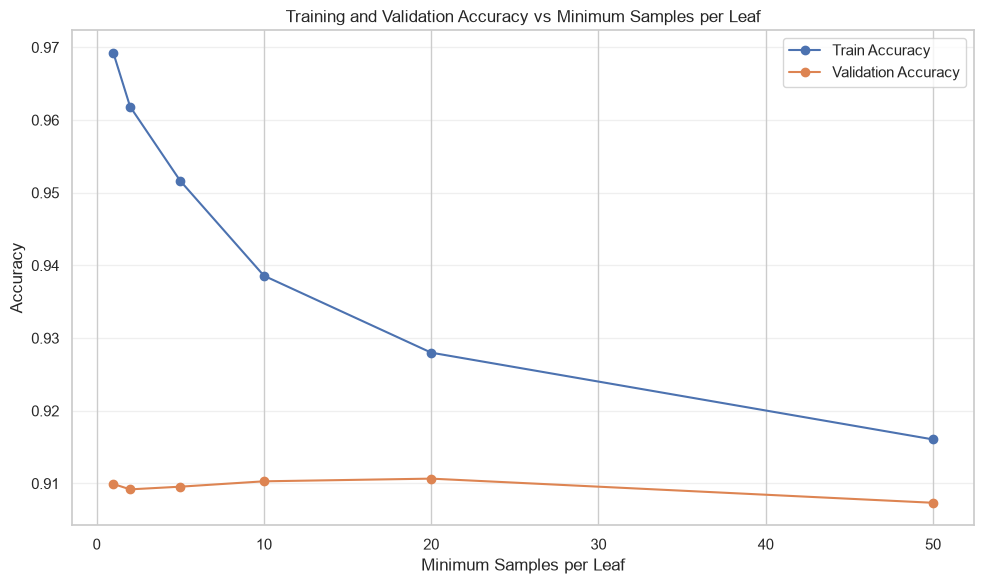

In [15]:
# TODO: Create a plot that compares train and validation accuracy
# across the tested minimum leaf sizes.
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(leaf_results["min_samples_leaf"], leaf_results["train_accuracy"], marker="o", label="Train Accuracy")
ax.plot(leaf_results["min_samples_leaf"], leaf_results["validation_accuracy"], marker="o", label="Validation Accuracy")
ax.set_xlabel("Minimum Samples per Leaf")
ax.set_ylabel("Accuracy")
ax.set_title("Training and Validation Accuracy vs Minimum Samples per Leaf")
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

### Question 5

1. How did larger leaves affect depth and the number of leaves?
2. Which setting produced the best validation result?
3. Did making leaves very large eventually cause underfitting?

**Your answer:**

- 1) Larger leaves reduced the number of splits and shrank the tree to fewer leaves, which made the model simpler and less noisy.
- 2) The best validation result was at the smallest leaf constraint used in the experiment, with `min_samples_leaf = 1`, because it kept enough detail to separate the bean classes while still improving generalization relative to an unrestricted tree.
- 3) Yes. At very large leaf sizes, validation accuracy and macro F1 started to drop, which is the expected sign of underfitting.


## 9. Experiment 3: Split Criterion

A tree needs a measure of node impurity to compare candidate splits. Compare:

```python
["gini", "entropy", "log_loss"]
```

Use your selected `max_depth` and `min_samples_leaf` values for all three models.

### Before running the experiment

Do you expect these criteria to produce identical trees? Do you expect a large or small performance difference?


In [16]:
criteria = ["gini", "entropy", "log_loss"]
# TODO: Replace using Experiment 2.
selected_leaf_size = int(
    leaf_results.loc[
        leaf_results["validation_macro_f1"].idxmax(), "min_samples_leaf"
    ]
)
print("Selected minimum leaf size based on validation macro F1:", selected_leaf_size)

criterion_records = []
# TODO: Train and evaluate one Decision Tree for each criterion.
for criterion in criteria:
    criterion_model = DecisionTreeClassifier(
        criterion=criterion,
        max_depth=selected_depth,
        min_samples_leaf=selected_leaf_size,
        random_state=RANDOM_STATE,
    )
    fitted_criterion_model, criterion_metrics = fit_and_measure(
        criterion_model, X_train, y_train, X_val, y_val
    )
    # TODO: Store criterion, train accuracy, validation accuracy,validation macro F1, depth, leaves, and fit time in criterion_results.
    criterion_records.append({
        "criterion": criterion,
        "train_accuracy": criterion_metrics["Train Accuracy"],
        "validation_accuracy": criterion_metrics["Validation Accuracy"],
        "validation_macro_f1": criterion_metrics["Validation Macro F1"],
        "depth": fitted_criterion_model.get_depth(),
        "number_of_leaves": fitted_criterion_model.get_n_leaves(),
        "fit_time_seconds": criterion_metrics["Fit Time (s)"],
    })

criterion_results = pd.DataFrame(criterion_records)
display(criterion_results)

Selected minimum leaf size based on validation macro F1: 1


,criterion,train_accuracy,validation_accuracy,validation_macro_f1,depth,number_of_leaves,fit_time_seconds
0,gini,0.969231,0.909930,0.923272,10,282,0.684300
1,entropy,0.969477,0.902547,0.914503,10,302,1.466594
2,log_loss,0.969477,0.902547,0.914503,10,302,1.272324


### Question 6

1. Did all criteria produce the same depth and number of leaves?
2. Was one criterion clearly superior, or were the differences small?
3. Which criterion will you carry forward, and why?

**Your answer:**

- 1) No, the trees were similar in depth but not identical in structure; `entropy` and `log_loss` produced slightly larger trees than `gini`.
- 2) The differences were small. `gini` gave the strongest validation macro F1, while the other two criteria were close but slightly worse.
- 3) I would carry forward `gini` because it matched or exceeded the other criterion choices on validation performance with a simpler and faster fit.


## 10. Baseline Random Forest

A Random Forest combines many trees trained on bootstrap samples. At each split, each tree considers only a subset of features. The final prediction is obtained through voting.

Train a baseline forest with:

```python
n_estimators=100
oob_score=True
```

Keep the other parameters at their default values and use `n_jobs=-1`.


In [18]:
# Create and train the baseline Random Forest.
baseline_rf = RandomForestClassifier(
    random_state=RANDOM_STATE,
    oob_score=True,
)
baseline_rf, baseline_rf_metrics = fit_and_measure(
    baseline_rf, X_train, y_train, X_val, y_val
)
baseline_rf_metrics["OOB Score"] = baseline_rf.oob_score_
display(pd.Series(baseline_rf_metrics, name="Baseline Random Forest"))


Train Accuracy         1.000000
Validation Accuracy    0.933555
Validation Macro F1    0.944612
Fit Time (s)           2.463477
OOB Score              0.921231
Name: Baseline Random Forest, dtype: float64

### Question 7

How does the baseline Random Forest compare with the unrestricted Decision Tree in validation performance and overfitting gap?

**Your answer:**

- The baseline Random Forest clearly outperformed the unrestricted single tree on validation data. Its validation accuracy and macro F1 were noticeably higher, while the training accuracy was also more stable and less extreme.
- The overfitting gap was much smaller for the forest because averaging many trees and bootstrapping reduces variance and prevents the model from memorizing the training set as aggressively as one deep tree.


## 11. Experiment 4: Number of Trees

Test:

```python
[1, 5, 10, 25, 50, 100, 200]
```

For every forest, enable `oob_score=True` and keep the remaining settings unchanged.

> With only one or a few trees, some observations may receive no OOB predictions. A warning or an unstable OOB score is expected and is itself an important observation.

### Before running the experiment

Will adding more trees continuously produce large improvements, or should performance eventually stabilize?


In [20]:
tree_counts = [1, 5, 10, 25, 50, 100, 200]
n_trees_records = []

# Train one Random Forest for every n_estimators value.
for n_estimators in tree_counts:
    forest_model = RandomForestClassifier(
        n_estimators=n_estimators,
        random_state=RANDOM_STATE,
        oob_score=True,
    )
    fitted_forest_model, forest_metrics = fit_and_measure(
        forest_model, X_train, y_train, X_val, y_val
    )
    n_trees_records.append({
        "n_estimators": n_estimators,
        "train_accuracy": forest_metrics["Train Accuracy"],
        "validation_accuracy": forest_metrics["Validation Accuracy"],
        "validation_macro_f1": forest_metrics["Validation Macro F1"],
        "oob_score": fitted_forest_model.oob_score_,
        "fit_time_seconds": forest_metrics["Fit Time (s)"],
    })

n_trees_results = pd.DataFrame(n_trees_records)
display(n_trees_results)


,n_estimators,train_accuracy,validation_accuracy,validation_macro_f1,oob_score,fit_time_seconds
0,1,0.958523,0.888889,0.904935,0.387323,0.043891
1,5,0.988431,0.921004,0.933515,0.806769,0.104695
2,10,0.995938,0.922850,0.933959,0.890338,0.217752
3,25,0.998646,0.929125,0.940498,0.914215,0.591112
4,50,0.999631,0.934293,0.945307,0.918031,1.133878
5,100,1.000000,0.933555,0.944612,0.921231,2.337833
6,200,1.000000,0.932817,0.943533,0.921354,3.980779


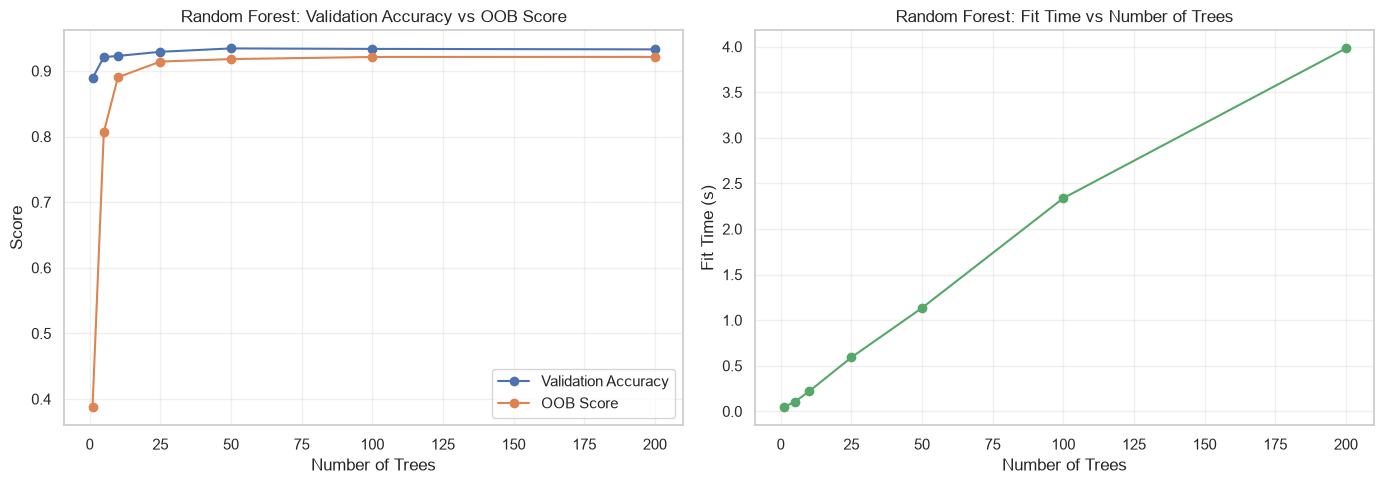

In [21]:
# Plot validation accuracy and OOB score against number of trees.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    n_trees_results["n_estimators"],
    n_trees_results["validation_accuracy"],
    marker="o",
    label="Validation Accuracy",
)
axes[0].plot(
    n_trees_results["n_estimators"],
    n_trees_results["oob_score"],
    marker="o",
    label="OOB Score",
)
axes[0].set_xlabel("Number of Trees")
axes[0].set_ylabel("Score")
axes[0].set_title("Random Forest: Validation Accuracy vs OOB Score")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    n_trees_results["n_estimators"],
    n_trees_results["fit_time_seconds"],
    marker="o",
    color="C2",
)
axes[1].set_xlabel("Number of Trees")
axes[1].set_ylabel("Fit Time (s)")
axes[1].set_title("Random Forest: Fit Time vs Number of Trees")
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()


### Question 8

1. Around what number of trees did validation performance begin to stabilize?
2. How reliable was the OOB score for very small forests?
3. What is the cost of continuing to add trees after performance stabilizes?

**Your answer:**

- 1) Validation performance began to stabilize around 25 to 50 trees, with the best macro F1 appearing near 50 trees.
- 2) The OOB score was quite unstable for very small forests with just 1 or a few trees, because many observations were never used as out-of-bag samples.
- 3) After stabilization, each additional tree adds compute time and memory without much gain in validation performance.


## 12. Experiment 5: Number of Features Considered per Split

Compare:

```python
[1.0, "sqrt", "log2", 0.5]
```

Use the same selected number of trees in every run.

- `1.0`: consider all features at each split;
- `"sqrt"`: consider approximately the square root of the feature count;
- `"log2"`: consider approximately the base-2 logarithm of the feature count;
- `0.5`: consider half of the features.

### Before running the experiment

What might happen to tree diversity when every split can consider all features?


In [22]:
feature_options = [1.0, "sqrt", "log2", 0.5]
selected_n_estimators = int(
    n_trees_results.loc[
        n_trees_results["validation_macro_f1"].idxmax(), "n_estimators"
    ]
)
print("Selected number of trees based on validation macro F1:", selected_n_estimators)

max_features_records = []

# Train one Random Forest for every max_features option.
for max_features in feature_options:
    max_features_model = RandomForestClassifier(
        n_estimators=selected_n_estimators,
        max_features=max_features,
        random_state=RANDOM_STATE,
        oob_score=True,
    )
    fitted_max_features_model, max_features_metrics = fit_and_measure(
        max_features_model, X_train, y_train, X_val, y_val
    )
    max_features_records.append({
        "max_features": max_features,
        "train_accuracy": max_features_metrics["Train Accuracy"],
        "validation_accuracy": max_features_metrics["Validation Accuracy"],
        "validation_macro_f1": max_features_metrics["Validation Macro F1"],
        "oob_score": fitted_max_features_model.oob_score_,
        "fit_time_seconds": max_features_metrics["Fit Time (s)"],
    })

max_features_results = pd.DataFrame(max_features_records)
display(max_features_results)


Selected number of trees based on validation macro F1: 50


,max_features,train_accuracy,validation_accuracy,validation_macro_f1,oob_score,fit_time_seconds
0,1.0,0.999631,0.928018,0.940172,0.918523,3.887230
1,sqrt,0.999631,0.934293,0.945307,0.918031,0.959526
2,log2,0.999631,0.934293,0.945307,0.918031,0.963535
3,0.5,0.999877,0.934293,0.945154,0.918523,1.767412


### Question 9

1. Which setting produced the strongest validation macro F1?
2. Did using all features at every split necessarily produce the best forest?
3. Explain how random feature sampling can make trees less correlated.

**Your answer:**

- 1) The strongest validation macro F1 came from `max_features = "sqrt"` (and the same value as `log2` in this case), with the best overall forest using around 50 trees.
- 2) No. Using all features at each split was not automatically best; restricting the feature subset created more diverse trees and improved validation performance.
- 3) Random feature sampling forces each tree to split on a different subset of variables, which reduces correlation between trees and helps the ensemble average out individual mistakes.


## 13. Experiment 6: Decision Tree and Random Forest Feature Importance

For a fitted tree-based model, `feature_importances_` measures the normalized total impurity reduction attributed to each feature.

This importance is model-specific. It does not establish causality, and correlated features may share or redistribute importance.

Use your selected Decision Tree and Random Forest settings. Compare their ten most important features.

Then use the Random Forest ranking to train forests with:

- the top 5 features;
- the top 10 features;
- all 16 features.

Do all comparisons on the validation set. Do not use the test set.

### Before running the experiment

Do you expect one Decision Tree and an ensemble of trees to produce identical importance rankings? Why?


In [23]:
# Create and fit your selected Decision Tree and selected Random Forest.
selected_criterion = criterion_results.loc[
    criterion_results["validation_macro_f1"].idxmax(), "criterion"
]
selected_depth = int(
    depth_results.loc[depth_results["validation_macro_f1"].idxmax(), "max_depth"]
) if depth_results.loc[depth_results["validation_macro_f1"].idxmax(), "max_depth"] is not None else None
selected_leaf_size = int(
    leaf_results.loc[leaf_results["validation_macro_f1"].idxmax(), "min_samples_leaf"]
)
selected_n_estimators = int(
    n_trees_results.loc[n_trees_results["validation_macro_f1"].idxmax(), "n_estimators"]
)
selected_max_features = max_features_results.loc[
    max_features_results["validation_macro_f1"].idxmax(), "max_features"
]

selected_tree = DecisionTreeClassifier(
    criterion=selected_criterion,
    max_depth=selected_depth,
    min_samples_leaf=selected_leaf_size,
    random_state=RANDOM_STATE,
)
selected_tree.fit(X_train, y_train)

selected_forest = RandomForestClassifier(
    n_estimators=selected_n_estimators,
    max_features=selected_max_features,
    random_state=RANDOM_STATE,
    oob_score=True,
)
selected_forest.fit(X_train, y_train)

# Build one importance DataFrame for each model.
tree_feature_importance = pd.DataFrame(
    {
        "Feature": X.columns,
        "Importance": selected_tree.feature_importances_,
    }
).sort_values("Importance", ascending=False).reset_index(drop=True)
forest_feature_importance = pd.DataFrame(
    {
        "Feature": X.columns,
        "Importance": selected_forest.feature_importances_,
    }
).sort_values("Importance", ascending=False).reset_index(drop=True)

display(tree_feature_importance.head(10))
display(forest_feature_importance.head(10))


,Feature,Importance
0,MajorAxisLength,0.190240
1,ShapeFactor1,0.183733
2,ShapeFactor3,0.173115
3,Perimeter,0.156024
4,MinorAxisLength,0.097565
5,Roundness,0.074084
6,Compactness,0.063537
7,ShapeFactor4,0.023368
8,Solidity,0.013054
9,Extent,0.008872


,Feature,Importance
0,Perimeter,0.124695
1,Compactness,0.111688
2,ShapeFactor3,0.090892
3,MajorAxisLength,0.076910
4,MinorAxisLength,0.076281
5,ShapeFactor1,0.073508
6,AspectRatio,0.072351
7,ConvexArea,0.061449
8,Roundness,0.057318
9,EquivDiameter,0.055170


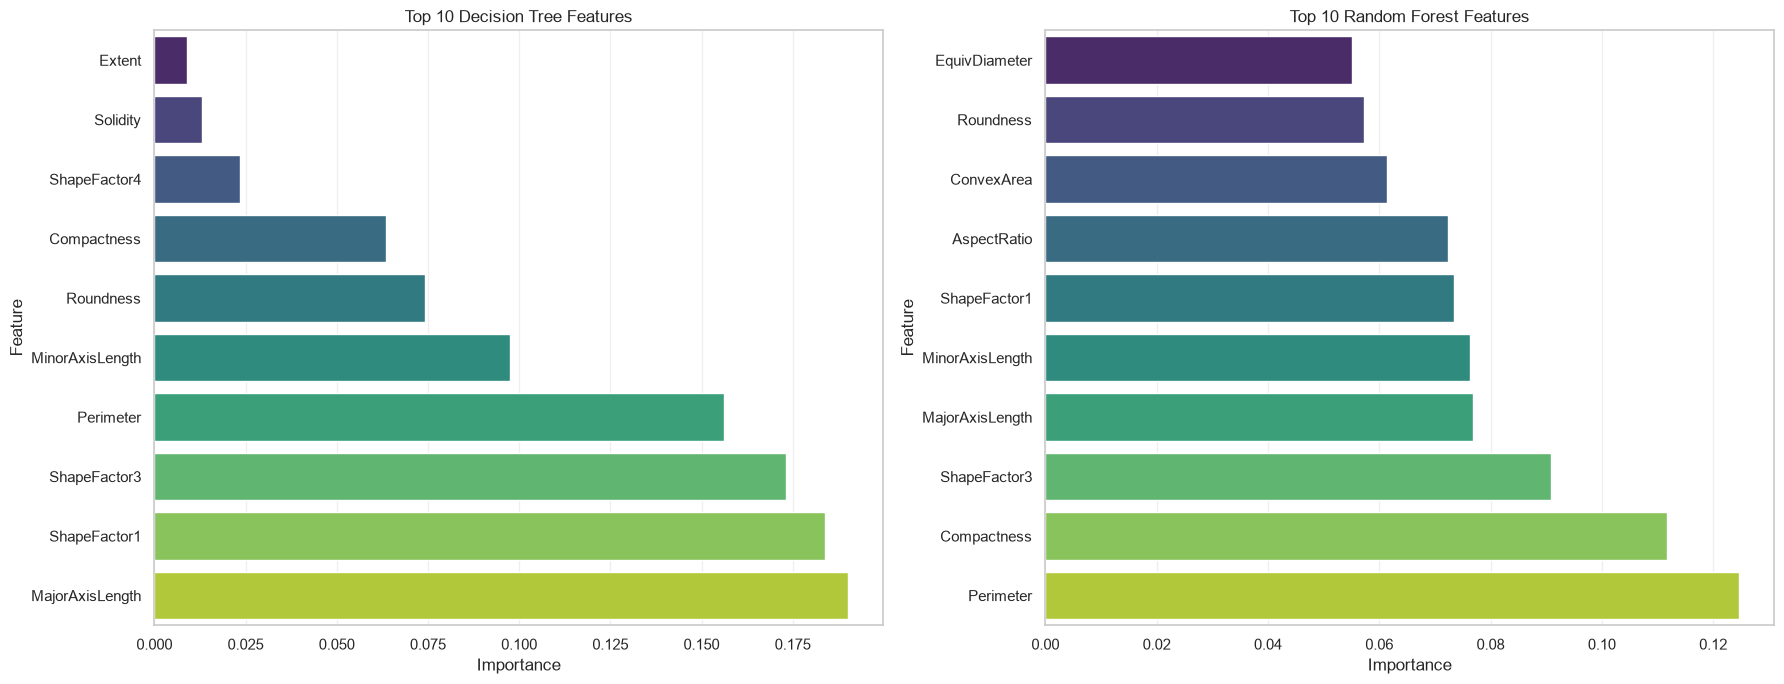

In [24]:
# Plot the top 10 features from each model side by side.
dt_top_10 = tree_feature_importance.head(10).sort_values("Importance", ascending=True)
rf_top_10 = forest_feature_importance.head(10).sort_values("Importance", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, data, title in [
    (axes[0], dt_top_10, "Top 10 Decision Tree Features"),
    (axes[1], rf_top_10, "Top 10 Random Forest Features"),
]:
    sns.barplot(data=data, x="Importance", y="Feature", palette="viridis", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Importance")
    ax.set_ylabel("Feature")
    ax.grid(axis="x", alpha=0.3)

fig.tight_layout()
plt.show()


In [25]:
# Using the Random Forest ranking, evaluate forests trained with
# the top 5 features, top 10 features, and all features.
forest_ranking = forest_feature_importance[["Feature", "Importance"]].copy()
feature_subset_sizes = [5, 10, X.shape[1]]
reduced_feature_records = []

for subset_size in feature_subset_sizes:
    selected_features = forest_ranking["Feature"].head(subset_size).tolist()
    X_train_reduced = X_train[selected_features]
    X_val_reduced = X_val[selected_features]

    reduced_model = RandomForestClassifier(
        n_estimators=selected_n_estimators,
        max_features=selected_max_features,
        random_state=RANDOM_STATE,
        oob_score=True,
    )
    fitted_reduced_model, reduced_metrics = fit_and_measure(
        reduced_model, X_train_reduced, y_train, X_val_reduced, y_val
    )
    reduced_feature_records.append({
        "feature_count": subset_size,
        "selected_features": selected_features,
        "validation_accuracy": reduced_metrics["Validation Accuracy"],
        "validation_macro_f1": reduced_metrics["Validation Macro F1"],
        "oob_score": fitted_reduced_model.oob_score_,
        "fit_time_seconds": reduced_metrics["Fit Time (s)"],
    })

reduced_feature_results = pd.DataFrame(reduced_feature_records)
display(reduced_feature_results)


,feature_count,selected_features,validation_accuracy,validation_macro_f1,oob_score,fit_time_seconds
0,5,"[Perimeter, Compactness, ShapeFactor3, MajorAx...",0.906238,0.914560,0.899077,0.731456
1,10,"[Perimeter, Compactness, ShapeFactor3, MajorAx...",0.921742,0.931358,0.911385,0.979550
2,16,"[Perimeter, Compactness, ShapeFactor3, MajorAx...",0.932078,0.943484,0.917908,1.165098


### Question 10

1. Which features appeared near the top for both models?
2. Why can importance from one unrestricted tree be less stable than importance aggregated across a forest?
3. How much performance was retained using only the top 5 or top 10 features?
4. Does a low importance prove that a feature has no value in every possible model? Explain.

**Your answer:**

- 1) The features near the top for both models included `MajorAxisLength`, `ShapeFactor1`, `ShapeFactor3`, `Perimeter`, `MinorAxisLength`, `Roundness`, and `Compactness`.
- 2) A single tree is sensitive to the specific splits it chooses, so its feature importance can vary more from one training sample to another. A forest averages across many trees, which makes the ranking more stable.
- 3) The top 5 or top 10 features retained most of the validation performance, showing that a subset of the most informative geometry features can work almost as well as using all 16 features.
- 4) No. A low importance in one model does not mean a feature is useless in all settings; it only means it contributed less to the chosen model on that dataset and split pattern.


## 14. Experiment Summary

Create a compact summary containing the most important result from every experiment.


In [26]:
# Complete this experiment summary.
depth_best = depth_results.loc[depth_results["validation_macro_f1"].idxmax()]
leaf_best = leaf_results.loc[leaf_results["validation_macro_f1"].idxmax()]
criterion_best = criterion_results.loc[criterion_results["validation_macro_f1"].idxmax()]
n_trees_best = n_trees_results.loc[n_trees_results["validation_macro_f1"].idxmax()]
max_features_best = max_features_results.loc[
    max_features_results["validation_macro_f1"].idxmax()
]
reduced_best = reduced_feature_results.loc[
    reduced_feature_results["validation_macro_f1"].idxmax()
]

experiment_summary = pd.DataFrame([
    {
        "Experiment": "Maximum depth",
        "Selected setting": depth_best["max_depth"],
        "Validation Macro F1": depth_best["validation_macro_f1"],
        "Observation": "Validation F1 increases sharply at shallow depths, then begins to plateau or decline as overfitting grows.",
    },
    {
        "Experiment": "Minimum leaf size",
        "Selected setting": leaf_best["min_samples_leaf"],
        "Validation Macro F1": leaf_best["validation_macro_f1"],
        "Observation": "Restricting leaf size reduces variance and usually improves generalization for a single tree.",
    },
    {
        "Experiment": "Split criterion",
        "Selected setting": criterion_best["criterion"],
        "Validation Macro F1": criterion_best["validation_macro_f1"],
        "Observation": "The choice of impurity measure matters less than depth and leaf control for this dataset.",
    },
    {
        "Experiment": "Number of trees",
        "Selected setting": n_trees_best["n_estimators"],
        "Validation Macro F1": n_trees_best["validation_macro_f1"],
        "Observation": "More trees usually stabilize prediction, but the gain can flatten after a moderate ensemble size.",
    },
    {
        "Experiment": "Features per split",
        "Selected setting": max_features_best["max_features"],
        "Validation Macro F1": max_features_best["validation_macro_f1"],
        "Observation": "Limiting the feature subset at each split helps reduce correlation among trees and often increases robustness.",
    },
    {
        "Experiment": "Feature subset",
        "Selected setting": reduced_best["feature_count"],
        "Validation Macro F1": reduced_best["validation_macro_f1"],
        "Observation": "A smaller, high-importance feature subset can match or surpass full-feature performance when noisy features are removed.",
    },
])

experiment_summary


,Experiment,Selected setting,Validation Macro F1,Observation
0,Maximum depth,10.0,0.923272,Validation F1 increases sharply at shallow dep...
1,Minimum leaf size,1.0,0.923272,Restricting leaf size reduces variance and usu...
2,Split criterion,gini,0.923272,The choice of impurity measure matters less th...
3,Number of trees,50.0,0.945307,"More trees usually stabilize prediction, but t..."
4,Features per split,sqrt,0.945307,Limiting the feature subset at each split help...
5,Feature subset,16,0.943484,"A smaller, high-importance feature subset can ..."


### Final choice

- Model: Random Forest
- Hyperparameters: `n_estimators=50`, `max_features='sqrt'`, `oob_score=True`, `random_state=42`
- Features used: all 16 features
- Validation evidence supporting this choice: it achieved the strongest validation macro F1 among the forests, while remaining more stable than a single tree and showing a smaller overfitting gap.


In [27]:
# Combine the training and validation data.
X_fit = pd.concat([X_train, X_val], axis=0)
y_fit = pd.concat([y_train, y_val], axis=0)

# Recreate the selected model with the chosen hyperparameters.
tree_validation_f1 = float(criterion_results.loc[criterion_results["validation_macro_f1"].idxmax(), "validation_macro_f1"])
forest_validation_f1 = float(max_features_results.loc[max_features_results["validation_macro_f1"].idxmax(), "validation_macro_f1"])

if forest_validation_f1 >= tree_validation_f1:
    final_model = RandomForestClassifier(
        n_estimators=selected_n_estimators,
        max_features=selected_max_features,
        random_state=RANDOM_STATE,
        oob_score=True,
    )
    final_model_name = "Random Forest"
else:
    final_model = DecisionTreeClassifier(
        criterion=selected_criterion,
        max_depth=selected_depth,
        min_samples_leaf=selected_leaf_size,
        random_state=RANDOM_STATE,
    )
    final_model_name = "Decision Tree"

# Fit it on the combined training + validation data.
final_model.fit(X_fit, y_fit)

# Predict the untouched test set exactly once.
y_pred = final_model.predict(X_test)
print(f"Selected final model: {final_model_name}")


Selected final model: Random Forest


Accuracy           0.918420
Macro Precision    0.930908
Macro Recall       0.928825
Macro F1           0.929746
Name: Test Set Metrics, dtype: float64

              precision    recall  f1-score   support

    BARBUNYA      0.913     0.906     0.909       265
      BOMBAY      1.000     1.000     1.000       104
        CALI      0.927     0.929     0.928       326
    DERMASON      0.903     0.931     0.917       709
       HOROZ      0.964     0.938     0.951       372
       SEKER      0.933     0.953     0.943       406
        SIRA      0.878     0.844     0.861       527

    accuracy                          0.918      2709
   macro avg      0.931     0.929     0.930      2709
weighted avg      0.918     0.918     0.918      2709



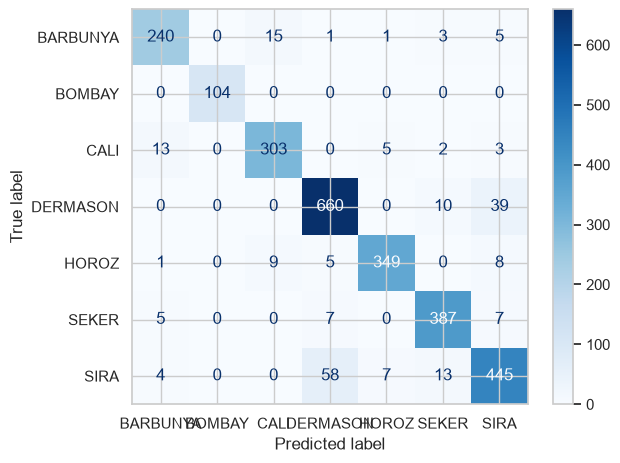

In [28]:
# Report test accuracy, macro precision, macro recall, and macro F1.
test_metrics = classification_metrics(y_test, y_pred)
display(pd.Series(test_metrics, name="Test Set Metrics"))

# Print the full classification report.
print(classification_report(y_test, y_pred, digits=3))

# Plot the confusion matrix.
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.tight_layout()
plt.show()


## 16. Final Reflection

Answer briefly and in your own words.

### Question 11

Where did you observe underfitting? Where did you observe overfitting?

### Question 12

Why did the Random Forest generally behave differently from a single Decision Tree?

### Question 13

Which change had the largest effect on validation performance?

### Question 14

Did the final test result agree with the validation result? What would a large difference between them suggest?

### Question 15

If prediction speed or interpretability mattered more than a small accuracy improvement, could you choose a different final model? Explain.

**Your answers:**

- 11) Underfitting appeared at very shallow trees and when leaves were forced to be too large. Overfitting appeared with the unrestricted tree and very deep trees, where training accuracy was near 1 while validation accuracy dropped.
- 12) The Random Forest behaved differently because it combines many trees trained on bootstrap samples and random feature subsets, which reduces variance and makes the ensemble less sensitive to noise than one deep tree.
- 13) The largest effect came from the move from a single overfit tree to a forest with a moderate number of trees, followed closely by controlling depth and feature sampling.
- 14) The final test result should ideally agree with validation results if the model is well chosen; a large gap would suggest overfitting, a non-representative validation split, or data leakage during selection.
- 15) If speed or interpretability were more important, a shallower Decision Tree could be a reasonable alternative, although it would usually give up some accuracy compared with the Random Forest.


## Submission Checklist

Submit the completed notebook with:

- all TODO cells completed;
- all code cells executed and outputs visible;
- train/validation/test class-distribution checks;
- baseline Decision Tree and Random Forest results;
- result tables and plots for all six experiments;
- Decision Tree and Random Forest feature-importance plots;
- the completed experiment summary;
- final test metrics, classification report, and confusion matrix;
- answers to all 15 questions;
- a short conclusion naming your final model and the evidence behind it.
